# LMUL gem5 Workflow

This notebook walks you through the full LMUL vs IEEE gem5 workflow:

1. (Optional) Environment checks and one-time setup.
2. Build the BF16 matrix-multiply benchmark.
3. Run `compare_lmul_vs_ieee.sh` for a list of matrix sizes.
4. Concatenate the generated `performance_comparison_*.txt` files into one summary.

> **Usage assumption:** Start Jupyter with the current working directory set to `gem5-sim/`.
> All paths below are relative to this folder.


In [1]:
from pathlib import Path
import subprocess
from utils.utils import plot_table, parse_performance_comparison_txt
import re
import pandas as pd

GEM5_SIM = Path.cwd()
REPO_ROOT = GEM5_SIM.parent

print(f"GEM5_SIM = {GEM5_SIM}")
print(f"REPO_ROOT = {REPO_ROOT}")


GEM5_SIM = /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim
REPO_ROOT = /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration


## 1. Check system compatability

In [ ]:
# # Uncomment to run

# scripts = [
#     REPO_ROOT / "gem5-sim" / "scripts" / "check_compatibility.sh",
#     REPO_ROOT / "gem5-sim" / "scripts" / "test_accelerator.sh",
# ]

# for script in scripts:
#     subprocess.run([str(script)], cwd=REPO_ROOT, check=True)

## 2. One-time setup

This command builds the gem5 model and may require significant time and memory.


In [ ]:
# # Uncomment to run

# build_gem5 = REPO_ROOT / "gem5-sim" / "scripts" / "install_model.sh"
# print(f"Building gem5 model in: {build_gem5}")
# subprocess.run(build_gem5, cwd=REPO_ROOT, check=True)

## 3. Build the BF16 matrix-multiply benchmark

This uses the existing Makefile in `benchmarks/matrix_multiply/` to build `matrix_multiply_no_printf.arm`.


In [3]:
# # Uncomment to run
# mm_dir = GEM5_SIM / "benchmarks" / "matrix_multiply"
# print(f"Building in: {mm_dir}")

# subprocess.run(["make", "matrix_multiply_no_printf.arm"], cwd=mm_dir, check=True)


## 4. Run LMUL vs IEEE comparisons for multiple sizes

Configure the sizes, PE array, and CPU model here. The cells below will call
`gem5-sim/scripts/compare_lmul_vs_ieee.sh` once per size.


In [11]:
# Experiment configuration
SIZES = [4, 64] # [4, 64, 256, 512] for full tests
PE_ROWS = 8
PE_COLS = 8
CPU_MODEL = "o3"           # "timing" (slower simulation, faster runtime) or "o3" (faster simulation, slower runtime)
INCLUDE_CPU_LMUL = True # Set to False to skip CPU LMUL runs
EXTRACT_OUTPUTS = True # Set to True to validate output results

compare_script = REPO_ROOT / "gem5-sim" / "scripts" / "compare_lmul_vs_ieee.sh"


In [12]:
# Uncomment to run the comparison scripts
# for n in SIZES:
#     cmd = [
#         str(compare_script),
#         "--size", str(n),
#         "--pe-rows", str(PE_ROWS),
#         "--pe-cols", str(PE_COLS),
#         "--cpu-model", CPU_MODEL,
#     ]
#     if n < 512 and INCLUDE_CPU_LMUL:
#         cmd.append("--include-cpu-lmul")
#     if not EXTRACT_OUTPUTS:
#         cmd.append("--no-output-extraction")

#     print("\nRunning:", " ".join(cmd))
#     result = subprocess.run(cmd, cwd=REPO_ROOT)
#     if result.returncode != 0:
#         print(f"Command failed for size {n} (exit {result.returncode})")
#         break


## 5. Check Output Validation



In [13]:
validate_script = GEM5_SIM / "scripts" / "validate_result_against_reference.py"
results_root = GEM5_SIM / "lmul_vs_ieee_comparison"

if EXTRACT_OUTPUTS:
    for n in SIZES:
        run_dirs = {
            "lmul": results_root / "lmul",
            "ieee": results_root / "ieee",
            "cpu_lmul": results_root / "cpu_lmul",
        }
        size_result = f"result_{n}.bin"
        size_inputs = f"inputs_{n}.bin"

        print(f"\n=== Validation for size {n} ===")

        # LMUL accelerator vs LMUL software reference
        if run_dirs["lmul"].is_dir():
            print("[LMUL Accel vs LMUL reference]")
            result_path = run_dirs["lmul"] / size_result
            inputs_path = run_dirs["lmul"] / size_inputs
            if not result_path.is_file() and (run_dirs["lmul"] / "result.bin").is_file():
                result_path = run_dirs["lmul"] / "result.bin"
                inputs_path = run_dirs["lmul"] / "inputs.bin"
            if result_path.is_file() and inputs_path.is_file():
                subprocess.run(
                    [
                        "python3",
                        str(validate_script),
                        str(run_dirs["lmul"]),
                        "--mode",
                        "lmul",
                        "--result",
                        str(result_path),
                        "--inputs",
                        str(inputs_path),
                    ],
                    cwd=GEM5_SIM,
                    check=False,
                )
            else:
                print(f"Missing LMUL artifacts for size {n}; skipping ({result_path.name}, {inputs_path.name}).")
        else:
            print("LMUL run directory missing; skipping.")

        # CPU LMUL (if present)
        if run_dirs["cpu_lmul"].is_dir():
            print("[CPU LMUL vs LMUL reference]")
            result_path = run_dirs["cpu_lmul"] / size_result
            inputs_path = run_dirs["cpu_lmul"] / size_inputs
            if not result_path.is_file() and (run_dirs["cpu_lmul"] / "result.bin").is_file():
                result_path = run_dirs["cpu_lmul"] / "result.bin"
                inputs_path = run_dirs["cpu_lmul"] / "inputs.bin"
            if result_path.is_file() and inputs_path.is_file():
                subprocess.run(
                    [
                        "python3",
                        str(validate_script),
                        str(run_dirs["cpu_lmul"]),
                        "--mode",
                        "lmul",
                        "--result",
                        str(result_path),
                        "--inputs",
                        str(inputs_path),
                    ],
                    cwd=GEM5_SIM,
                    check=False,
                )
            else:
                print(f"Missing CPU LMUL artifacts for size {n}; skipping ({result_path.name}, {inputs_path.name}).")

        # IEEE CPU vs IEEE software reference
        if run_dirs["ieee"].is_dir():
            print("[IEEE CPU vs IEEE reference]")
            result_path = run_dirs["ieee"] / size_result
            inputs_path = run_dirs["ieee"] / size_inputs
            if not result_path.is_file() and (run_dirs["ieee"] / "result.bin").is_file():
                result_path = run_dirs["ieee"] / "result.bin"
                inputs_path = run_dirs["ieee"] / "inputs.bin"
            if result_path.is_file() and inputs_path.is_file():
                subprocess.run(
                    [
                        "python3",
                        str(validate_script),
                        str(run_dirs["ieee"]),
                        "--mode",
                        "ieee",
                        "--result",
                        str(result_path),
                        "--inputs",
                        str(inputs_path),
                    ],
                    cwd=GEM5_SIM,
                    check=False,
                )
            else:
                print(f"Missing IEEE artifacts for size {n}; skipping ({result_path.name}, {inputs_path.name}).")
        else:
            print("IEEE run directory missing; skipping.")
else:
    print("Output validation skipped (EXTRACT_OUTPUTS is False).")


=== Validation for size 4 ===
[LMUL Accel vs LMUL reference]


Error: result file not found: /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim/lmul_vs_ieee_comparison/lmul/result.bin


[IEEE CPU vs IEEE reference]


Error: result file not found: /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim/lmul_vs_ieee_comparison/ieee/result.bin



=== Validation for size 64 ===
[LMUL Accel vs LMUL reference]


Error: result file not found: /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim/lmul_vs_ieee_comparison/lmul/result.bin


[IEEE CPU vs IEEE reference]


Error: result file not found: /Users/owen/Desktop/classes/dsc180/LMUL-Hardware-Acceleration/gem5-sim/lmul_vs_ieee_comparison/ieee/result.bin


## 6. Parse performance_comparison_*.txt into a summary table

This cell parses all available `performance_comparison_<size>.txt` files,
extracts **Simulation Time (s)**, **CPU Cycles**, and **Estimated total energy (µJ)**
for each path (LMUL Accel, IEEE, and CPU LMUL when present), and builds a
`pandas` DataFrame similar to the **Core Results Breakdown** table in `results.ipynb`.

It also writes the raw concatenated text to `performance_comparison_all.txt` for convenience.


In [7]:
out_dir = GEM5_SIM / "lmul_vs_ieee_comparison"
concat_path = out_dir / "performance_comparison_all.txt"

all_rows = []

for n in SIZES:
    path = out_dir / f"performance_comparison_{n}.txt"
    if not path.is_file():
        print(f"Missing: {path}")
        continue

    all_rows.extend(parse_performance_comparison_txt(path, size=n))

if all_rows:
    core = pd.DataFrame(all_rows)

    # Normalize path names so utils.plot_table() receives expected labels.
    core["Path"] = core["Path"].replace({
        "LMUL": "LMUL ACL",
        "LMUL Accel": "LMUL ACL",
        "IEEE CPU": "IEEE",
    })

    core = core.sort_values(["Size", "Path"]).reset_index(drop=True)
    display(core)
else:
    print("No performance comparison rows parsed.")

,Size,Path,Sim Time (s),CPU Cycles,Energy (µJ)
0,4,CPU LMUL,0.000731,1461464,1768.679
1,4,IEEE,0.000695,1390385,1683.884
2,4,LMUL ACL,0.000558,1116025,1349.731
3,64,CPU LMUL,0.489043,978086011,1166332.164
4,64,IEEE,0.130199,260397405,314422.902
5,64,LMUL ACL,0.009969,19938925,23602.373


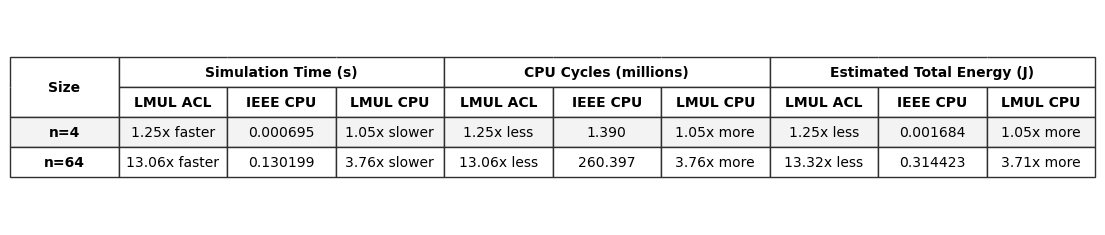

In [8]:
plot_table(SIZES, core)